Text(0, 0.5, 'E')

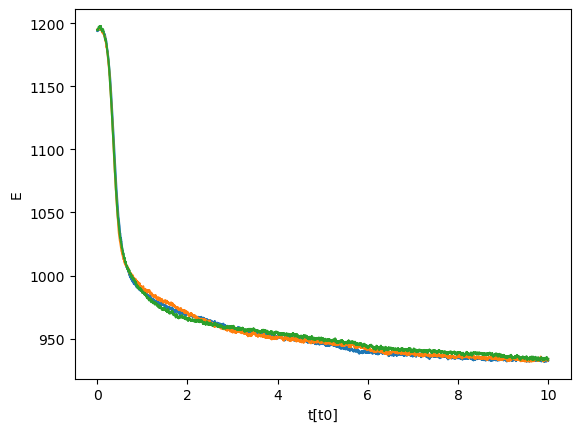

In [6]:
#plot free Energy

import numpy as np 
import matplotlib.pyplot as plt

data=np.loadtxt('E_sample1.dat')
plt.plot(data[:,0],data[:,1]) 
data=np.loadtxt('E_sample10.dat')
plt.plot(data[:,0],data[:,1]) 
data=np.loadtxt('E_sample15.dat')
plt.plot(data[:,0],data[:,1]) 
plt.xlabel('t[t0]')
plt.ylabel('E')



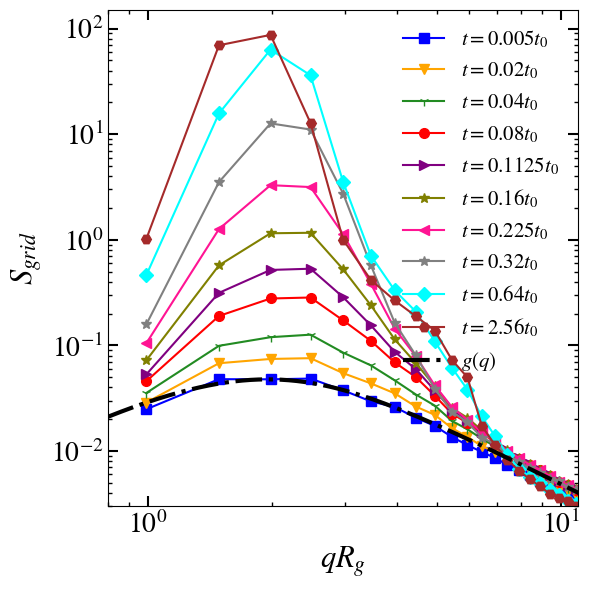

In [14]:
#plot the structure factors S(q)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
colors = ['blue','orange','forestgreen','red', 'purple','olive','deeppink','gray','cyan','brown','black','pink','gold','lightblue','darkviolet','darkorange']
markers = ['s', 'v','1','o','>','*','<','*','D','H','P','X','|','_','1','2','3','4','8']
# List of sample indices you used
samples_to_try = [2,8,16,32,45,64,90,128,256,1024]

plt.figure(figsize=(6, 6))
n=0
for sample_index in samples_to_try:
    filename = f"radial_profile_sample{sample_index}.dat"
    try:
        data = np.loadtxt(filename)
        q_values = data[:, 0]
        S_q_values = data[:, 1]
        plt.loglog(q_values, S_q_values, label=f'$t= {sample_index*50*0.00005}t_0$',marker=markers[n], ms=7, fillstyle='full', ls='-',color=colors[n])
    except Exception as e:
        print(f"Could not read file {filename}: {e}")
    n+=1
def g(x):
    return (2/x**2)*(np.exp(-x)-1+x)
f=0.5
gamma=[]
kaa=[]
kbb=[]
kab=[]
r=0.01
q_max=12
q_min=0.8
R_g=1.
for k in np.arange(q_min, q_max, r):
    K_AA =f**2*g(f*k**2*R_g**2)
    K_BB =(1-f)**2*g((1-f)*k**2*R_g**2)
    K_AB = 0.5*(g(k**2*R_g**2)-K_AA-K_BB)
    kaa=np.append(kaa,K_AA)
    kbb=np.append(kbb,K_BB)
    kab=np.append(kab,K_AB)
    gamma=np.append(gamma,((K_AA+K_BB+2*K_AB)/(K_AA*K_BB - K_AB**2)))

plt.loglog(np.arange(q_min, q_max, r), 1.0 / np.array(gamma), lw=3, label=r'$g(q)$',color='k',ls='-.')
plt.tick_params(which='major', direction='in', length=7, width=1.5, labelsize=20, right=True, top=True)
plt.tick_params(which='minor', direction='in', length=3, width=1, labelsize=16, right=True,top=True)
plt.xlim(0.8, 11)
plt.ylim(3e-3,)
plt.xlabel(r'$q R_g$',fontsize=22)
plt.ylabel(r'$S_{grid}$',fontsize=22)

plt.legend(fontsize=15,frameon=False)
plt.tight_layout()
plt.savefig("radial_profiles_combined.png", dpi=300)
plt.show()


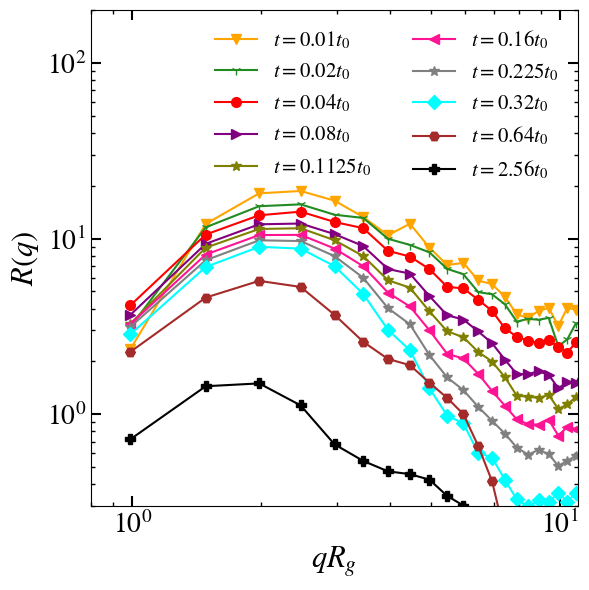

In [1]:
#plot the average growth rate [R(q)]
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
colors = ['blue','orange','forestgreen','red', 'purple','olive','deeppink','gray','cyan','brown','black','pink','gold','lightblue','darkviolet','darkorange']
markers = ['s', 'v','1','o','>','*','<','*','D','H','P','X','|','_','1','2','3','4','8']
# List of sample indices you used
samples_to_try = [0,4,8,16,32,45,64,90,128,256,1024]

plt.figure(figsize=(6, 6))
n=0
for sample_index in samples_to_try:
    filename = f"radial_profile_sample{sample_index}.dat"
    try:
        data = np.loadtxt(filename)
        if n==0: s0=data[:, 1]
        q_values = data[:, 0]
        S_q_values = data[:, 1]
        if n>0:plt.loglog(q_values, np.log(S_q_values/s0)/(2*sample_index*50*0.00005), label=f'$t= {sample_index*50*0.00005}t_0$',marker=markers[n], ms=7, fillstyle='full', ls='-',color=colors[n])
    except Exception as e:
        print(f"Could not read file {filename}: {e}")
    n+=1
def g(x):
    return (2/x**2)*(np.exp(-x)-1+x)
f=0.5
gamma=[]
kaa=[]
kbb=[]
kab=[]
r=0.01
q_max=12
q_min=0.8
R_g=1.
for k in np.arange(q_min, q_max, r):
    K_AA =f**2*g(f*k**2*R_g**2)
    K_BB =(1-f)**2*g((1-f)*k**2*R_g**2)
    K_AB = 0.5*(g(k**2*R_g**2)-K_AA-K_BB)
    kaa=np.append(kaa,K_AA)
    kbb=np.append(kbb,K_BB)
    kab=np.append(kab,K_AB)
    gamma=np.append(gamma,((K_AA+K_BB+2*K_AB)/(K_AA*K_BB - K_AB**2)))

#plt.loglog(np.arange(q_min, q_max, r), 1.0 / np.array(gamma), lw=3, label=r'$g(q)$',color='k',ls='-.')
plt.tick_params(which='major', direction='in', length=7, width=1.5, labelsize=20, right=True, top=True)
plt.tick_params(which='minor', direction='in', length=3, width=1, labelsize=16, right=True,top=True)
plt.xlim(0.8, 11)
plt.ylim(3e-1,200)
plt.xlabel(r'$q R_g$',fontsize=22)
plt.ylabel(r'$R(q)$',fontsize=22)

plt.legend(fontsize=15,frameon=False,ncol=2)
plt.tight_layout()
plt.savefig("R_q_1.0.png", dpi=300)
plt.show()
